# Mapping CA counties data

### Setup

In [10]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

### Load base map

In [2]:
counties_gdf = gpd.read_file('../data/California_County_Boundaries_and_Identifiers_Blue_Version_view_5222979114348197495.geojson')

In [5]:
counties_gdf.shape

(58, 16)

In [6]:
counties_gdf.head()

,OBJECTID,CDTFA_COUNTY,CDTFA_COPRI,CENSUS_PLACE_NAME,CENSUS_GEOID,CENSUS_PLACE_TYPE,GNIS_PLACE_NAME,GNIS_ID,CDT_COUNTY_ABBR,PRIMARY_DOMAIN,CENSUS_POPULATION,CDT_NAME_SHORT,OFFSHORE,AREA_SQMI,GlobalID,geometry
0,82,Alameda County,01000,Alameda County,06001,County,Alameda County,1675839.0,ALA,None,None,Alameda,None,746.722082,bb9da43d-5418-4c34-b53d-e4af9e649ddc,"POLYGON ((-136862.653 -21116.482, -136862.975 ..."
1,83,Alpine County,02000,Alpine County,06003,County,Alpine County,1675840.0,ALP,None,None,Alpine,None,743.406638,a225a45a-a02f-4f19-a22f-d5225f0c1e3f,"POLYGON ((35904.446 77650.345, 35916.626 77625..."
2,84,Amador County,03000,Amador County,06005,County,Amador County,1675841.0,AMA,None,None,Amador,None,606.008407,0f4abdae-2752-4796-96f6-ebf67b3d7301,"POLYGON ((-6292.983 76302.406, -6296.823 74295..."
3,85,Butte County,04000,Butte County,06007,County,Butte County,1675842.0,BUT,None,None,Butte,None,1677.815777,88912ea1-8137-459f-bb73-bb5decc0be65,"POLYGON ((-92396.332 176240.347, -92655.136 17..."
4,86,Calaveras County,05000,Calaveras County,06009,County,Calaveras County,1675885.0,CAL,None,None,Calaveras,None,1035.546618,35fb3f14-130b-40df-b575-172f53d2b67e,"POLYGON ((-1744.777 46376.992, -1748.283 46367..."


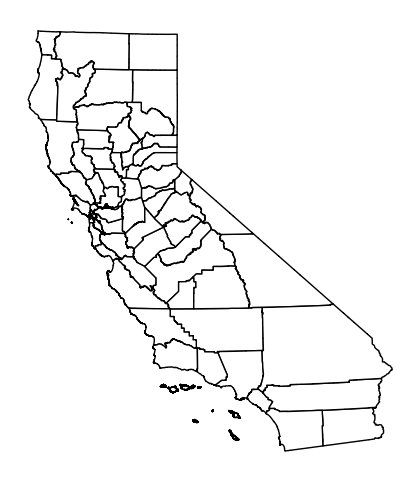

In [14]:
counties_gdf.plot(color='white', edgecolor='black', figsize=(6,6))
plt.axis('off')
plt.show()

### Load some ddata

In [15]:
acs5_final = pd.read_csv('../data/ACSDP05_final.csv')

* Join map `GeoDataFrame` with the ACS data
* Can we use the `county` string

In [18]:
acs5_final['county'].head()

0      Alameda County
1       Alpine County
2       Amador County
3        Butte County
4    Calaveras County
Name: county, dtype: str

In [20]:
counties_gdf['CDTFA_COUNTY'].head()

0      Alameda County
1       Alpine County
2       Amador County
3        Butte County
4    Calaveras County
Name: CDTFA_COUNTY, dtype: str

In [24]:
combined_gdf = counties_gdf.merge(acs5_final, 
                                  left_on = 'CDTFA_COUNTY',
                                  right_on = 'county')

combined_gdf.shape

(58, 24)

In [25]:
combined_gdf.head()

,OBJECTID,CDTFA_COUNTY,CDTFA_COPRI,CENSUS_PLACE_NAME,CENSUS_GEOID,CENSUS_PLACE_TYPE,GNIS_PLACE_NAME,GNIS_ID,CDT_COUNTY_ABBR,PRIMARY_DOMAIN,...,GlobalID,geometry,county,median_age,pct_white,pct_black,pct_native,pct_asian,pct_other,pct_hispanic
0,82,Alameda County,01000,Alameda County,06001,County,Alameda County,1675839.0,ALA,None,...,bb9da43d-5418-4c34-b53d-e4af9e649ddc,"POLYGON ((-136862.653 -21116.482, -136862.975 ...",Alameda County,38.7,41.8,12.1,2.1,36.1,19.1,23.3
1,83,Alpine County,02000,Alpine County,06003,County,Alpine County,1675840.0,ALP,None,...,a225a45a-a02f-4f19-a22f-d5225f0c1e3f,"POLYGON ((35904.446 77650.345, 35916.626 77625...",Alpine County,41.1,71.0,0.0,28.1,0.5,8.3,14.7
2,84,Amador County,03000,Amador County,06005,County,Amador County,1675841.0,AMA,None,...,0f4abdae-2752-4796-96f6-ebf67b3d7301,"POLYGON ((-6292.983 76302.406, -6296.823 74295...",Amador County,49.9,89.0,3.7,5.0,3.6,12.3,15.5
3,85,Butte County,04000,Butte County,06007,County,Butte County,1675842.0,BUT,None,...,88912ea1-8137-459f-bb73-bb5decc0be65,"POLYGON ((-92396.332 176240.347, -92655.136 17...",Butte County,36.3,84.3,3.1,4.3,7.1,13.6,19.5
4,86,Calaveras County,05000,Calaveras County,06009,County,Calaveras County,1675885.0,CAL,None,...,35fb3f14-130b-40df-b575-172f53d2b67e,"POLYGON ((-1744.777 46376.992, -1748.283 46367...",Calaveras County,52.0,91.6,1.6,3.8,3.2,10.8,13.9


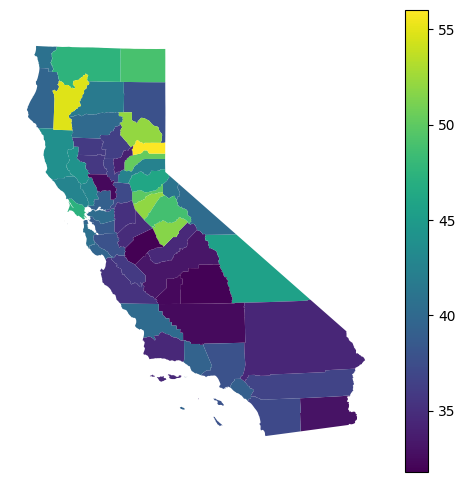

In [29]:
combined_gdf.plot(column='median_age', figsize=(6,6), legend=True)
plt.axis('off')
plt.show()